# Diffusion action-signal characterization (offline, desk, no arm)

Provenance: the DDIM-10 hardware run was violent enough to break a sensor; before the arm
moves again we measure the waveform on the desk. Decomposes "violence" into
(a) intra-chunk noise per scheduler, (b) stochastic re-plan seam magnitude, leaving
(c) sync stop-go timing as the residual if both come back clean. ACT on the same frames =
deterministic reference; dataset ground-truth deltas = smoothness floor. All deltas in
native action units (degrees), comparable to the planned `max_relative_target=5` clamp.

Run on the Mac (mps), `lerobot` conda env. Policy cells are independent — run ACT and
DDIM-10 first (cheap), DDPM-100 last (~9s/chunk dominates runtime). Re-running a policy
cell replaces its records, no duplicates.

In [42]:
# ---------------- CONFIG ----------------
from pathlib import Path

REPO_ROOT = Path("/Users/tamara/Google Drive/act-diffusion-vla-so101")

# Frozen 50-episode training dataset (same data all three policies trained on)
DATASET_REPO_ID = "TamaraSumarac/so101_policy_robustness"
DATASET_ROOT = Path.home() / "datasets/act-diffusion-vla-so101/so101_policy_robustness" # local path if cached, else None

DIFF_CKPT_ORIGINAL = REPO_ROOT / "checkpoints_diffusion_baseline" / "100000" / "pretrained_model"        # DDPM-100 as trained
DIFF_CKPT_DDIM10  = REPO_ROOT / "checkpoints_diffusion_baseline" / "100000_ddim10"
DIFF_CKPT_DDIM50  = REPO_ROOT / "checkpoints_diffusion_baseline" / "100000_ddim50" / "pretrained_model"   # created below
ACT_CKPT          = REPO_ROOT / "checkpoints_act_baseline" / "100000" / "pretrained_model"              # act

DEVICE = "mps"

EPISODES = [0, 1, 2, 3, 4]
N_SEAM_FRAMES = 30        # (t, t+n) pairs total across episodes
N_RESAMPLE_FRAMES = 10    # frames for K-sample stochastic spread
K_RESAMPLES = 6
N_ACTION_STEPS_LIST = [8, 16]
SEED = 17

OUT_DIR = REPO_ROOT / "perturbation" / "follow-up results" / "diffusion" / "results" / "diffusion_signal"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# ---------------- imports ----------------
import json, os
import numpy as np
import torch

from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.policies.act.modeling_act import ACTPolicy
from lerobot.policies.diffusion.modeling_diffusion import DiffusionPolicy

torch.manual_seed(SEED)
np.random.seed(SEED)
records = []  # global accumulator across policy cells

objc[47805]: Class AVFFrameReceiver is implemented in both /Users/tamara/miniforge3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x14a9703a8) and /Users/tamara/miniforge3/envs/lerobot/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x165a003a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[47805]: Class AVFAudioReceiver is implemented in both /Users/tamara/miniforge3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x14a9703f8) and /Users/tamara/miniforge3/envs/lerobot/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x165a003f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


In [3]:
# ---------------- DDIM-50 variant (config.json surgery, symlinked weights) ----------------
# Only override path that works: post-load config mutation and from_pretrained kwargs
# were both verified ineffective (see results_diffusion.md).
def ensure_scheduler_variant(src, dst, scheduler, steps):
    if dst.exists():
        print(f"exists: {dst.name}")
        return
    dst.mkdir(parents=True)
    for f in src.iterdir():
        if f.name == "config.json":
            continue
        os.symlink(f.resolve(), dst / f.name)
    cfg = json.loads((src / "config.json").read_text())
    cfg["noise_scheduler_type"] = scheduler
    cfg["num_inference_steps"] = steps
    (dst / "config.json").write_text(json.dumps(cfg, indent=2))
    print(f"created {dst.name}: {scheduler}-{steps}")

ensure_scheduler_variant(DIFF_CKPT_ORIGINAL, DIFF_CKPT_DDIM50, "DDIM", 50)
# print(DIFF_CKPT_ORIGINAL)
# print(DIFF_CKPT_DDIM50)
# print(DIFF_CKPT_DDIM50.exists(), DIFF_CKPT_ORIGINAL.samefile(DIFF_CKPT_DDIM50) if DIFF_CKPT_DDIM50.exists() else "-")
# print(DIFF_CKPT_DDIM50.is_symlink())
# DIFF_CKPT_DDIM50.unlink()          # removes the link only
print(json.loads((DIFF_CKPT_DDIM10 / "config.json").read_text())["noise_scheduler_type"])
print(json.loads((DIFF_CKPT_DDIM50 / "config.json").read_text())["noise_scheduler_type"],
      json.loads((DIFF_CKPT_DDIM50 / "config.json").read_text())["num_inference_steps"])

exists: pretrained_model
DDIM
DDIM 50


In [26]:
# ---------------- helpers ----------------
from lerobot.policies.factory import make_pre_post_processors

def make_dataset(policy_cfg):
    """LeRobotDataset whose __getitem__ stacks obs to the policy's n_obs_steps
    via delta_timestamps, mirroring training collation. Sidesteps select_action's
    obs queues entirely (the thing the async server gets wrong for diffusion)."""
    probe = LeRobotDataset(DATASET_REPO_ID, root=DATASET_ROOT)
    fps = probe.fps
    delta_timestamps = {}
    obs_idx = getattr(policy_cfg, "observation_delta_indices", None)
    if obs_idx:
        for key in probe.meta.features:
            if key.startswith("observation."):
                delta_timestamps[key] = [i / fps for i in obs_idx]
    act_idx = getattr(policy_cfg, "action_delta_indices", None)
    if act_idx:
        delta_timestamps["action"] = [i / fps for i in act_idx]
    return LeRobotDataset(DATASET_REPO_ID, root=DATASET_ROOT,
                          delta_timestamps=delta_timestamps or None)

def episode_bounds(ds, ep):
    edi = getattr(ds, "episode_data_index", None)
    if edi is not None:
        return int(edi["from"][ep]), int(edi["to"][ep])
    ep_col = np.asarray(ds.hf_dataset["episode_index"])
    idx = np.nonzero(ep_col == ep)[0]
    return int(idx[0]), int(idx[-1]) + 1

def load_policy(cls, ckpt):
    """Policy + its checkpoint's own pre/post processor pipelines (v0.6:
    normalization lives in the processors, not the policy). Auto-handles the
    per-policy difference (ACT mean-std vs diffusion min-max)."""
    policy = cls.from_pretrained(str(ckpt)).to(DEVICE).eval()
    pre, post = make_pre_post_processors(
        policy.config, pretrained_path=str(ckpt),
        preprocessor_overrides={"device_processor": {"device": DEVICE}},
    )
    return policy, pre, post

def get_chunk(policy, pre, post, item):
    """Full predicted action chunk in DEGREES, (horizon, action_dim)."""
    obs = {k: v for k, v in item.items() if k.startswith("observation.")}
    if "task" in item:
        obs["task"] = item["task"]
    policy.reset()
    with torch.no_grad():
        batch = pre(obs)
        if isinstance(policy, DiffusionPolicy):
            # pre() can't add a batch dim here: history-stacked (2, 6) looks
            # already-batched to its ndim check. Add it ourselves, then build
            # OBS_IMAGES and call generate_actions on the real history.
            batch = {k: (v.unsqueeze(0) if torch.is_tensor(v) else v)
                     for k, v in batch.items()}
            batch["observation.images"] = torch.stack(
                [batch[k] for k in policy.config.image_features], dim=-4)
            chunk = policy.diffusion.generate_actions(batch)
        else:
            chunk = policy.predict_action_chunk(batch)
    chunk = post(chunk)
    return chunk.squeeze(0).float().cpu().numpy()

def check_units(chunk, label):
    # SO-101 joint positions in degrees always span well past 5; a chunk living
    # entirely in O(1) means a processor was skipped.
    if np.abs(chunk).max() < 5:
        print(f"[WARN] {label}: |chunk|max={np.abs(chunk).max():.2f} — looks "
              f"NORMALIZED, processor pipeline not applied. Fix before trusting numbers.")

def intra_chunk_stats(chunk):
    d = np.abs(np.diff(chunk, axis=0))
    j = np.abs(np.diff(chunk, n=2, axis=0))
    return {"delta_mean": d.mean(), "delta_p95": np.percentile(d, 95),
            "delta_max": d.max(), "jerk_p95": np.percentile(j, 95) if len(j) else 0.0}

In [27]:
# ---------------- sampling plan + dataset smoothness floor (run once) ----------------
_probe = LeRobotDataset(DATASET_REPO_ID, root=DATASET_ROOT)
rng = np.random.default_rng(SEED)
seam_pairs = []   # (t_idx, t_idx + n, n) — global frame indices, valid for every policy
max_n = max(N_ACTION_STEPS_LIST)
per_ep = max(1, N_SEAM_FRAMES // (len(EPISODES) * len(N_ACTION_STEPS_LIST)))
for ep in EPISODES:
    lo, hi = episode_bounds(_probe, ep)
    for t in rng.choice(np.arange(lo + 5, hi - max_n - 5), size=per_ep, replace=False):
        for n in N_ACTION_STEPS_LIST:
            seam_pairs.append((int(t), int(t) + n, n))
resample_frames = sorted({p[0] for p in seam_pairs})[:N_RESAMPLE_FRAMES]
print(f"{len(seam_pairs)} seam pairs, {len(resample_frames)} resample frames")

# ground-truth deltas = what smooth demo motion looks like, in degrees
gt = []
for ep in EPISODES:
    lo, hi = episode_bounds(_probe, ep)
    acts = np.stack([np.atleast_1d(_probe[i]["action"].numpy()) for i in range(lo, hi)])
    gt.append(np.abs(np.diff(acts, axis=0)))
gt = np.concatenate(gt)
records[:] = [r for r in records if r["policy"] != "dataset_gt"]
records.append({"policy": "dataset_gt", "kind": "intra", "delta_mean": gt.mean(),
                "delta_p95": np.percentile(gt, 95), "delta_max": gt.max()})
print(f"dataset_gt  delta_mean={gt.mean():.3f}  p95={np.percentile(gt,95):.3f}  max={gt.max():.3f}")

30 seam pairs, 10 resample frames
dataset_gt  delta_mean=0.334  p95=1.846  max=5.978


In [28]:
# ---------------- analysis runner ----------------
def run_policy_analysis(name, cls, ckpt, stochastic):
    global records
    records = [r for r in records if r["policy"] != name]  # rerun-safe
    print(f"=== {name} ({ckpt}) ===")
    policy, pre, post = load_policy(cls, ckpt)
    if hasattr(policy, "diffusion"):
        print("scheduler:", type(policy.diffusion.noise_scheduler).__name__,
              "steps:", policy.config.num_inference_steps)
    ds = make_dataset(policy.config)

    units_checked = False
    for i, (t_idx, t_next_idx, n_exec) in enumerate(seam_pairs):
        chunk_a = get_chunk(policy, pre, post, ds[t_idx])
        chunk_b = get_chunk(policy, pre, post, ds[t_next_idx])
        if not units_checked:
            check_units(chunk_a, name); units_checked = True
        rec = {"policy": name, "kind": "seam", "n_exec": n_exec, "frame": t_idx,
               **intra_chunk_stats(chunk_a)}
        if n_exec < chunk_a.shape[0]:
            rec["seam_jump_max"] = np.abs(chunk_b[0] - chunk_a[n_exec - 1]).max()
            # overlap: both predictions target the SAME timestep -> pure re-plan
            # inconsistency, no motion excuse
            rec["overlap_disagree_max"] = np.abs(chunk_b[0] - chunk_a[n_exec]).max()
        records.append(rec)
        print(f"  seam {i+1}/{len(seam_pairs)} n_exec={n_exec} "
              f"d_p95={rec['delta_p95']:.2f} seam={rec.get('seam_jump_max', float('nan')):.2f}")

    if stochastic:
        for i, t_idx in enumerate(resample_frames):
            item = ds[t_idx]
            chunks = np.stack([get_chunk(policy, pre, post, item)
                               for _ in range(K_RESAMPLES)])
            spread = chunks.std(axis=0)
            records.append({"policy": name, "kind": "resample", "frame": t_idx,
                            "spread_mean": spread.mean(), "spread_max": spread.max(),
                            "spread_step0_max": spread[0].max()})
            print(f"  resample {i+1}/{len(resample_frames)} "
                  f"spread_mean={spread.mean():.2f} step0_max={spread[0].max():.2f}")

    del policy
    if DEVICE == "mps":
        torch.mps.empty_cache()

## Checks before policy runs:

In [29]:
p, pre, post = load_policy(ACTPolicy, ACT_CKPT)
c = get_chunk(p, pre, post, make_dataset(p.config)[seam_pairs[0][0]])
print("chunk[:2]:", c[:2].round(2))
print("dataset  :", np.atleast_1d(_probe[seam_pairs[0][0]]["action"].numpy()).round(2))
del p

Loading weights from local directory
chunk[:2]: [[ 21.75 -70.34  47.11  76.01  15.31  32.93]
 [ 21.84 -73.62  49.44  75.59  14.8   33.02]]
dataset  : [ 21.32 -65.45  41.76  76.09  15.6   33.  ]


In [30]:
policy, pre, post = load_policy(DiffusionPolicy, DIFF_CKPT_DDIM10)
print("n_obs_steps:", policy.config.n_obs_steps,
      "| delta_idx:", getattr(policy.config, "observation_delta_indices", "MISSING"))
ds = make_dataset(policy.config)
item = ds[seam_pairs[0][0]]
for k, v in item.items():
    if hasattr(v, "shape"): print("item:", k, tuple(v.shape))
obs = {k: v for k, v in item.items() if k.startswith("observation.")}
b = pre(obs)
for k, v in b.items():
    if hasattr(v, "shape"): print("pre :", k, tuple(v.shape))

Loading weights from local directory
n_obs_steps: 2 | delta_idx: [-1, 0]
item: observation.images.front (2, 3, 480, 640)
item: action (64, 6)
item: observation.state (2, 6)
item: timestamp ()
item: frame_index ()
item: episode_index ()
item: index ()
item: task_index ()
item: observation.state_is_pad (2,)
item: observation.images.front_is_pad (2,)
item: action_is_pad (64,)
pre : observation.state_is_pad (2,)
pre : observation.images.front_is_pad (2,)
pre : observation.images.front (2, 3, 480, 640)
pre : observation.state (2, 6)


## Policy runs — cheap first, DDPM-100 last

In [31]:
# ACT — deterministic reference (~seconds)
run_policy_analysis("act", ACTPolicy, ACT_CKPT, stochastic=False)

=== act (/Users/tamara/Google Drive/act-diffusion-vla-so101/checkpoints_act_baseline/100000/pretrained_model) ===
Loading weights from local directory
  seam 1/30 n_exec=8 d_p95=1.25 seam=1.85
  seam 2/30 n_exec=16 d_p95=1.25 seam=2.61
  seam 3/30 n_exec=8 d_p95=2.36 seam=1.23
  seam 4/30 n_exec=16 d_p95=2.36 seam=10.92
  seam 5/30 n_exec=8 d_p95=4.00 seam=5.47
  seam 6/30 n_exec=16 d_p95=4.00 seam=6.61
  seam 7/30 n_exec=8 d_p95=2.82 seam=2.85
  seam 8/30 n_exec=16 d_p95=2.82 seam=4.42
  seam 9/30 n_exec=8 d_p95=1.29 seam=1.58
  seam 10/30 n_exec=16 d_p95=1.29 seam=1.62
  seam 11/30 n_exec=8 d_p95=0.84 seam=3.02
  seam 12/30 n_exec=16 d_p95=0.84 seam=4.04
  seam 13/30 n_exec=8 d_p95=1.38 seam=0.94
  seam 14/30 n_exec=16 d_p95=1.38 seam=0.96
  seam 15/30 n_exec=8 d_p95=0.16 seam=0.56
  seam 16/30 n_exec=16 d_p95=0.16 seam=0.67
  seam 17/30 n_exec=8 d_p95=1.24 seam=1.24
  seam 18/30 n_exec=16 d_p95=1.24 seam=1.85
  seam 19/30 n_exec=8 d_p95=2.28 seam=0.76
  seam 20/30 n_exec=16 d_p95=2.

In [32]:
# DDIM-10 — the config that broke the sensor (~2 min)
run_policy_analysis("ddim10", DiffusionPolicy, DIFF_CKPT_DDIM10, stochastic=True)

=== ddim10 (/Users/tamara/Google Drive/act-diffusion-vla-so101/checkpoints_diffusion_baseline/100000_ddim10) ===
Loading weights from local directory
scheduler: DDIMScheduler steps: 10
  seam 1/30 n_exec=8 d_p95=3.02 seam=3.26
  seam 2/30 n_exec=16 d_p95=3.22 seam=2.81
  seam 3/30 n_exec=8 d_p95=2.51 seam=8.22
  seam 4/30 n_exec=16 d_p95=3.24 seam=31.96
  seam 5/30 n_exec=8 d_p95=2.19 seam=2.61
  seam 6/30 n_exec=16 d_p95=2.19 seam=7.83
  seam 7/30 n_exec=8 d_p95=1.81 seam=1.91
  seam 8/30 n_exec=16 d_p95=1.63 seam=2.82
  seam 9/30 n_exec=8 d_p95=0.41 seam=1.76
  seam 10/30 n_exec=16 d_p95=0.38 seam=1.54
  seam 11/30 n_exec=8 d_p95=1.15 seam=3.03
  seam 12/30 n_exec=16 d_p95=0.98 seam=2.98
  seam 13/30 n_exec=8 d_p95=1.05 seam=0.72
  seam 14/30 n_exec=16 d_p95=1.11 seam=1.16
  seam 15/30 n_exec=8 d_p95=0.44 seam=0.48
  seam 16/30 n_exec=16 d_p95=0.48 seam=1.38
  seam 17/30 n_exec=8 d_p95=0.58 seam=1.89
  seam 18/30 n_exec=16 d_p95=0.49 seam=0.97
  seam 19/30 n_exec=8 d_p95=3.72 seam=8.

In [33]:
# DDIM-50 (~10 min)
run_policy_analysis("ddim50", DiffusionPolicy, DIFF_CKPT_DDIM50, stochastic=True)

=== ddim50 (/Users/tamara/Google Drive/act-diffusion-vla-so101/checkpoints_diffusion_baseline/100000_ddim50/pretrained_model) ===
Loading weights from local directory
scheduler: DDIMScheduler steps: 50
  seam 1/30 n_exec=8 d_p95=3.22 seam=4.88
  seam 2/30 n_exec=16 d_p95=2.99 seam=1.46
  seam 3/30 n_exec=8 d_p95=3.33 seam=9.11
  seam 4/30 n_exec=16 d_p95=3.57 seam=21.46
  seam 5/30 n_exec=8 d_p95=2.15 seam=3.26
  seam 6/30 n_exec=16 d_p95=2.15 seam=4.80
  seam 7/30 n_exec=8 d_p95=1.66 seam=1.48
  seam 8/30 n_exec=16 d_p95=2.48 seam=1.01
  seam 9/30 n_exec=8 d_p95=0.42 seam=1.65
  seam 10/30 n_exec=16 d_p95=0.37 seam=2.02
  seam 11/30 n_exec=8 d_p95=1.42 seam=1.76
  seam 12/30 n_exec=16 d_p95=1.36 seam=3.38
  seam 13/30 n_exec=8 d_p95=1.05 seam=3.22
  seam 14/30 n_exec=16 d_p95=1.02 seam=1.16
  seam 15/30 n_exec=8 d_p95=0.39 seam=2.23
  seam 16/30 n_exec=16 d_p95=0.42 seam=1.36
  seam 17/30 n_exec=8 d_p95=0.48 seam=1.43
  seam 18/30 n_exec=16 d_p95=0.56 seam=0.79
  seam 19/30 n_exec=8 d

In [34]:
# DDPM-100 — as trained (~20-25 min on mps; offline so latency is free)
run_policy_analysis("ddpm100", DiffusionPolicy, DIFF_CKPT_ORIGINAL, stochastic=True)

=== ddpm100 (/Users/tamara/Google Drive/act-diffusion-vla-so101/checkpoints_diffusion_baseline/100000/pretrained_model) ===
Loading weights from local directory
scheduler: DDPMScheduler steps: None
  seam 1/30 n_exec=8 d_p95=3.22 seam=6.27
  seam 2/30 n_exec=16 d_p95=3.06 seam=2.79
  seam 3/30 n_exec=8 d_p95=2.54 seam=6.82
  seam 4/30 n_exec=16 d_p95=3.71 seam=18.53
  seam 5/30 n_exec=8 d_p95=2.26 seam=3.66
  seam 6/30 n_exec=16 d_p95=2.18 seam=5.17
  seam 7/30 n_exec=8 d_p95=1.96 seam=1.64
  seam 8/30 n_exec=16 d_p95=1.53 seam=2.75
  seam 9/30 n_exec=8 d_p95=0.37 seam=2.43
  seam 10/30 n_exec=16 d_p95=0.43 seam=2.16
  seam 11/30 n_exec=8 d_p95=1.36 seam=4.16
  seam 12/30 n_exec=16 d_p95=1.27 seam=4.35
  seam 13/30 n_exec=8 d_p95=1.08 seam=1.13
  seam 14/30 n_exec=16 d_p95=1.12 seam=1.14
  seam 15/30 n_exec=8 d_p95=0.47 seam=1.40
  seam 16/30 n_exec=16 d_p95=0.31 seam=1.53
  seam 17/30 n_exec=8 d_p95=0.73 seam=2.30
  seam 18/30 n_exec=16 d_p95=0.70 seam=2.85
  seam 19/30 n_exec=8 d_p95

## Summary

Read against the `dataset_gt` row and the 5° clamp:
- **d_p95 / d_max** ≫ dataset floor for DDIM-10 but not DDPM-100 → denoising quality; GPU + more steps fixes it.
- deltas near floor but **seam / ovlp** large → re-plan discontinuity; fix = longer executed chunks + seam handling.
- everything clean → violence was sync stop-go timing; remote inference is the whole fix.

`ovlp` is the cleanest seam number: both predictions target the same timestep, so disagreement is pure re-plan inconsistency.

In [37]:
# ---------------- summary table + CSV ----------------
import csv

keys = sorted({k for r in records for k in r})
with open(OUT_DIR / "signal_metrics.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=keys); w.writeheader(); w.writerows(records)

def agg(name, kind, field):
    vals = [r[field] for r in records
            if r["policy"] == name and r.get("kind") == kind and field in r]
    return np.mean(vals) if vals else float("nan")

names_run = [n for n in ["act", "ddim10", "ddim50", "ddpm100"]
             if any(r["policy"] == n for r in records)]

print("================ SUMMARY (degrees) ================")
print(f"{'policy':<12}{'d_p95':>8}{'d_max':>8}{'seam8':>8}{'seam16':>8}{'ovlp':>8}{'spread':>8}")
g = [r for r in records if r["policy"] == "dataset_gt"][0]
print(f"{'dataset_gt':<12}{g['delta_p95']:>8.2f}{g['delta_max']:>8.2f}{'-':>8}{'-':>8}{'-':>8}{'-':>8}")
for name in names_run:
    seam8  = np.mean([r["seam_jump_max"] for r in records
                      if r["policy"] == name and r.get("n_exec") == 8 and "seam_jump_max" in r] or [np.nan])
    seam16 = np.mean([r["seam_jump_max"] for r in records
                      if r["policy"] == name and r.get("n_exec") == 16 and "seam_jump_max" in r] or [np.nan])
    ovlp   = np.mean([r["overlap_disagree_max"] for r in records
                      if r["policy"] == name and "overlap_disagree_max" in r] or [np.nan])
    dmax   = np.mean([r["delta_max"] for r in records
                      if r["policy"] == name and "delta_max" in r] or [np.nan])
    print(f"{name:<12}{agg(name,'seam','delta_p95'):>8.2f}{dmax:>8.2f}"
          f"{seam8:>8.2f}{seam16:>8.2f}{ovlp:>8.2f}{agg(name,'resample','spread_mean'):>8.2f}")

print("\n---- top-5 seam jumps (deg, frame, n_exec) ----")
for name in names_run:
    s = sorted([(float(r["seam_jump_max"]), r["frame"], r["n_exec"]) for r in records
                if r["policy"] == name and "seam_jump_max" in r], reverse=True)[:5]
    print(f"{name:<12}", "  ".join(f"{v:5.1f}° (f{f}, n{n})" for v, f, n in s))

print(f"\nwrote {OUT_DIR / 'signal_metrics.csv'}")

================ SUMMARY (degrees) ================
policy         d_p95   d_max   seam8  seam16    ovlp  spread
dataset_gt      1.85    5.98       -       -       -       -
act             1.76    4.69    2.12    3.55    2.53     nan
ddim10          1.43    2.25    3.13    6.75    5.06    1.32
ddim50          1.52    2.39    3.07    3.66    3.44    1.28
ddpm100         1.47    2.41    2.93    4.31    3.69    1.08

---- top-5 seam jumps (deg, frame, n_exec) ----
act           10.9° (f58, n16)    6.6° (f375, n16)    6.2° (f1961, n8)    5.7° (f1961, n16)    5.5° (f375, n8)
ddim10        38.0° (f1664, n16)   32.0° (f58, n16)    8.2° (f58, n8)    8.1° (f1664, n8)    7.8° (f375, n16)
ddim50        21.5° (f58, n16)    9.1° (f58, n8)    8.6° (f1664, n16)    5.9° (f1664, n8)    4.9° (f428, n8)
ddpm100       18.5° (f58, n16)   15.6° (f1664, n16)    6.8° (f58, n8)    6.4° (f1961, n8)    6.3° (f428, n8)

wrote /Users/tamara/Google Drive/act-diffusion-vla-so101/results/diffusion_signal/signal_metr

plotting frame 1664 (ddim10 seam 38.0 deg, n_exec=16)
Loading weights from local directory


Loading weights from local directory


Loading weights from local directory


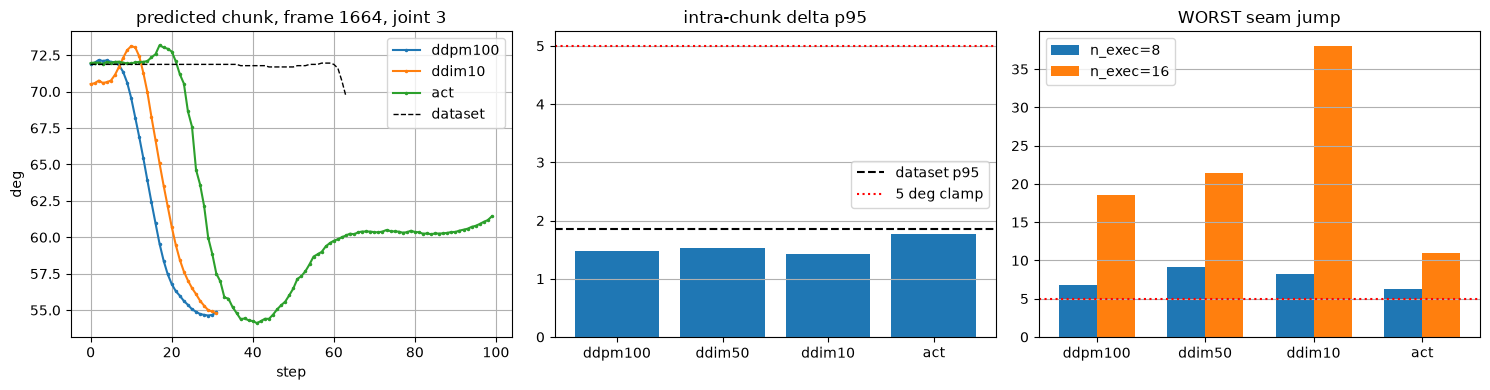

wrote /Users/tamara/Google Drive/act-diffusion-vla-so101/results/diffusion_signal/signal_summary.png


In [40]:
# ---------------- figure: example chunks + delta/seam distributions ----------------
import matplotlib.pyplot as plt

JOINT = 3
# pick the hottest ddim10 seam frame so panel 1 shows the pathology, not a calm frame
_hot = max([r for r in records if r["policy"] == "ddim10" and "seam_jump_max" in r],
           key=lambda r: r["seam_jump_max"])
t_idx = _hot["frame"]
print(f"plotting frame {t_idx} (ddim10 seam {_hot['seam_jump_max']:.1f} deg, n_exec={_hot['n_exec']})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# panel 1: one chunk per policy on the hot frame + dataset ground truth
for name, cls, ckpt in [("ddpm100", DiffusionPolicy, DIFF_CKPT_ORIGINAL),
                        ("ddim10", DiffusionPolicy, DIFF_CKPT_DDIM10),
                        ("act", ACTPolicy, ACT_CKPT)]:
    p, pre, post = load_policy(cls, ckpt)
    c = get_chunk(p, pre, post, make_dataset(p.config)[t_idx])
    axes[0].plot(c[:, JOINT], marker=".", ms=3, label=name)
    del p
horizon = 64
gt_trace = np.stack([np.atleast_1d(_probe[t_idx + s]["action"].numpy())
                     for s in range(horizon)])
axes[0].plot(gt_trace[:, JOINT], "k--", lw=1, label="dataset")
axes[0].set_title(f"predicted chunk, frame {t_idx}, joint {JOINT}")
axes[0].set_xlabel("step"); axes[0].set_ylabel("deg"); axes[0].legend(); axes[0].grid(True)

# panel 2: intra-chunk delta p95 per policy vs dataset floor
names = [n for n in ["ddpm100", "ddim50", "ddim10", "act"]
         if any(r["policy"] == n for r in records)]
axes[1].bar(names, [agg(n, "seam", "delta_p95") for n in names])
axes[1].axhline(g["delta_p95"], color="k", ls="--", label="dataset p95")
axes[1].axhline(5.0, color="r", ls=":", label="5 deg clamp")
axes[1].set_title("intra-chunk delta p95"); axes[1].legend(); axes[1].grid(True, axis="y")

# panel 3: WORST seam jump by n_exec (mean hides the sensor-breaking tail)
w = 0.35
for j, n_exec in enumerate(N_ACTION_STEPS_LIST):
    vals = [np.max([r["seam_jump_max"] for r in records
                    if r["policy"] == n and r.get("n_exec") == n_exec
                    and "seam_jump_max" in r] or [np.nan]) for n in names]
    axes[2].bar(np.arange(len(names)) + j * w, vals, width=w, label=f"n_exec={n_exec}")
axes[2].axhline(5.0, color="r", ls=":")
axes[2].set_xticks(np.arange(len(names)) + w / 2); axes[2].set_xticklabels(names)
axes[2].set_title("WORST seam jump"); axes[2].legend(); axes[2].grid(True, axis="y")

plt.tight_layout()
plt.savefig(OUT_DIR / "signal_summary.png", dpi=150)
plt.show()
print(f"wrote {OUT_DIR / 'signal_summary.png'}")

plotting frame 58 (ddim10 seam 38.0 deg, n_exec=16)
Loading weights from local directory


Loading weights from local directory


Loading weights from local directory


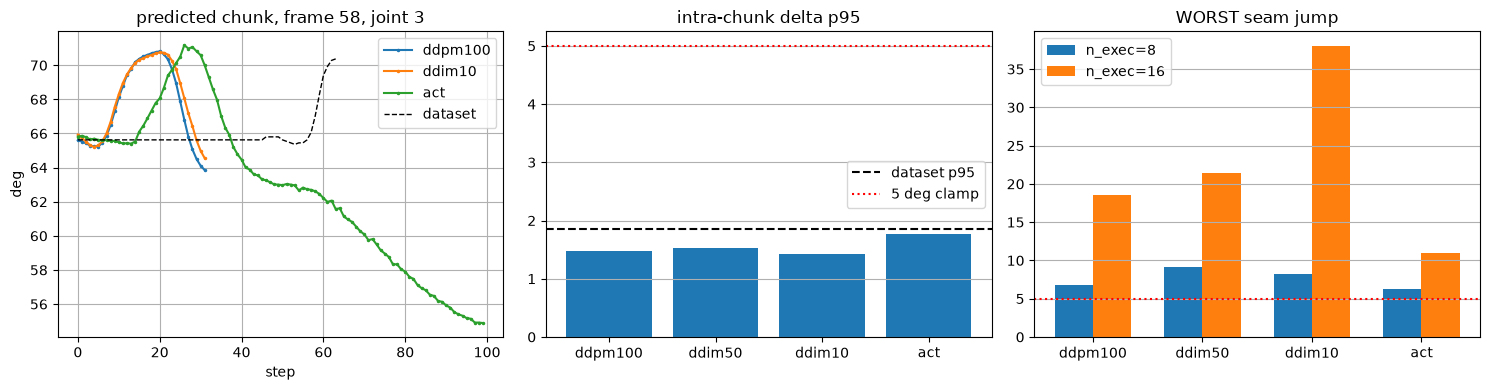

wrote /Users/tamara/Google Drive/act-diffusion-vla-so101/results/diffusion_signal/signal_summary.png


In [39]:
# ---------------- figure: example chunks + delta/seam distributions ----------------
import matplotlib.pyplot as plt

JOINT = 3
# pick the hottest ddim10 seam frame so panel 1 shows the pathology, not a calm frame
_hot = max([r for r in records if r["policy"] == "ddim10" and "seam_jump_max" in r],
           key=lambda r: r["seam_jump_max"])
t_idx = 58 #_hot["frame"]
print(f"plotting frame {t_idx} (ddim10 seam {_hot['seam_jump_max']:.1f} deg, n_exec={_hot['n_exec']})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# panel 1: one chunk per policy on the hot frame + dataset ground truth
for name, cls, ckpt in [("ddpm100", DiffusionPolicy, DIFF_CKPT_ORIGINAL),
                        ("ddim10", DiffusionPolicy, DIFF_CKPT_DDIM10),
                        ("act", ACTPolicy, ACT_CKPT)]:
    p, pre, post = load_policy(cls, ckpt)
    c = get_chunk(p, pre, post, make_dataset(p.config)[t_idx])
    axes[0].plot(c[:, JOINT], marker=".", ms=3, label=name)
    del p
horizon = 64
gt_trace = np.stack([np.atleast_1d(_probe[t_idx + s]["action"].numpy())
                     for s in range(horizon)])
axes[0].plot(gt_trace[:, JOINT], "k--", lw=1, label="dataset")
axes[0].set_title(f"predicted chunk, frame {t_idx}, joint {JOINT}")
axes[0].set_xlabel("step"); axes[0].set_ylabel("deg"); axes[0].legend(); axes[0].grid(True)

# panel 2: intra-chunk delta p95 per policy vs dataset floor
names = [n for n in ["ddpm100", "ddim50", "ddim10", "act"]
         if any(r["policy"] == n for r in records)]
axes[1].bar(names, [agg(n, "seam", "delta_p95") for n in names])
axes[1].axhline(g["delta_p95"], color="k", ls="--", label="dataset p95")
axes[1].axhline(5.0, color="r", ls=":", label="5 deg clamp")
axes[1].set_title("intra-chunk delta p95"); axes[1].legend(); axes[1].grid(True, axis="y")

# panel 3: WORST seam jump by n_exec (mean hides the sensor-breaking tail)
w = 0.35
for j, n_exec in enumerate(N_ACTION_STEPS_LIST):
    vals = [np.max([r["seam_jump_max"] for r in records
                    if r["policy"] == n and r.get("n_exec") == n_exec
                    and "seam_jump_max" in r] or [np.nan]) for n in names]
    axes[2].bar(np.arange(len(names)) + j * w, vals, width=w, label=f"n_exec={n_exec}")
axes[2].axhline(5.0, color="r", ls=":")
axes[2].set_xticks(np.arange(len(names)) + w / 2); axes[2].set_xticklabels(names)
axes[2].set_title("WORST seam jump"); axes[2].legend(); axes[2].grid(True, axis="y")

plt.tight_layout()
plt.savefig(OUT_DIR / "signal_summary.png", dpi=150)
plt.show()
print(f"wrote {OUT_DIR / 'signal_summary.png'}")

Loading weights from local directory


Loading weights from local directory


Loading weights from local directory


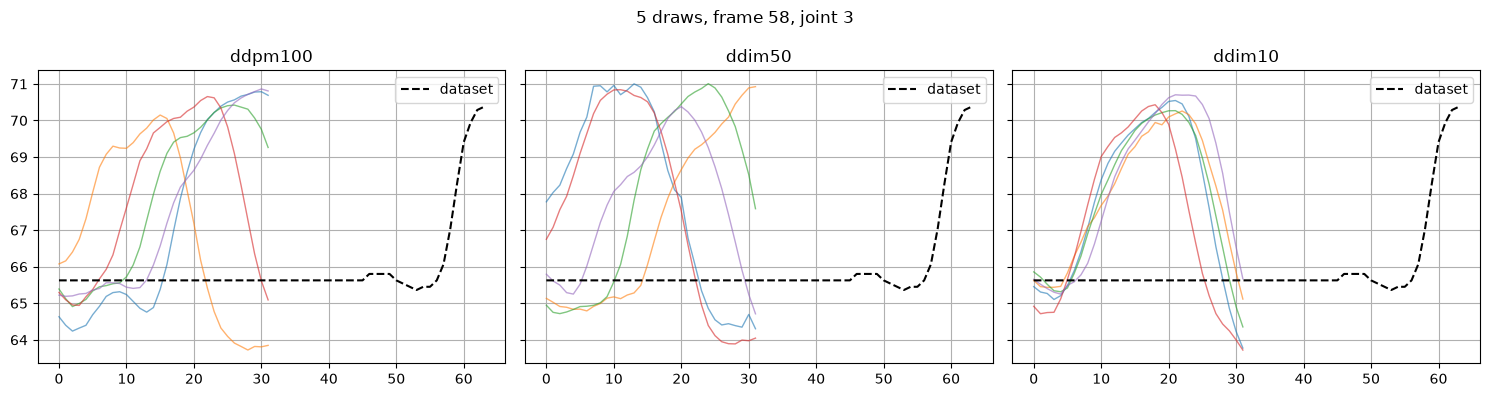

In [41]:
# ---------------- resample overlay at the hot frame ----------------
K, t_idx, JOINT = 5, 58, 3
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, ckpt) in zip(axes, [("ddpm100", DIFF_CKPT_ORIGINAL),
                                   ("ddim50", DIFF_CKPT_DDIM50),
                                   ("ddim10", DIFF_CKPT_DDIM10)]):
    p, pre, post = load_policy(DiffusionPolicy, ckpt)
    item = make_dataset(p.config)[t_idx]
    for _ in range(K):
        ax.plot(get_chunk(p, pre, post, item)[:, JOINT], alpha=0.6, lw=1)
    gt_trace = np.stack([np.atleast_1d(_probe[t_idx + s]["action"].numpy())
                         for s in range(64)])
    ax.plot(gt_trace[:, JOINT], "k--", lw=1.5, label="dataset")
    ax.set_title(name); ax.grid(True); ax.legend()
    del p
plt.suptitle(f"{K} draws, frame {t_idx}, joint {JOINT}")
plt.tight_layout(); plt.savefig(OUT_DIR / f"resample_overlay_f{t_idx}.png", dpi=150); plt.show()

## Server pipeline probe

In [49]:
# --- server-path debug A: joint ordering + features, robot vs training data ---
from lerobot.robots.so_follower import SO101FollowerConfig, SO101Follower
from lerobot.cameras.opencv import OpenCVCameraConfig
from lerobot.utils.feature_utils import hw_to_dataset_features

robot = SO101Follower(SO101FollowerConfig(
    port="/dev/tty.usbmodem5B610326031", id="so101_follower",
    cameras={"front": OpenCVCameraConfig(index_or_path=0, width=640, height=480, fps=30)}))
lerobot_features = hw_to_dataset_features(robot.observation_features, "observation", use_video=False)
print("features        :", list(lerobot_features.keys()))
print("robot state order :", lerobot_features["observation.state"]["names"])
print("dataset state order:", _probe.meta.features["observation.state"]["names"])

features        : ['observation.state', 'observation.images.front']
robot state order : ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']
dataset state order: ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']


In [50]:
# --- server-path debug B: replay the server's exact prep on a training frame ---
from lerobot.async_inference.helpers import (
    encode_jpeg_images, decode_jpeg_images, raw_observation_to_observation)

T = seam_pairs[0][0]
MOTOR_KEYS = list(_probe.meta.features["observation.state"]["names"])

def frame_to_raw(i):
    item = _probe[i]
    img = (item["observation.images.front"].permute(1, 2, 0) * 255).to(torch.uint8).numpy()
    raw = {"front": img}
    for name, val in zip(MOTOR_KEYS, item["observation.state"].numpy()):
        raw[name] = float(val)
    raw["task"] = "Pick up the pink block and place it in the plate"
    return raw

policy, pre, post = load_policy(DiffusionPolicy, DIFF_CKPT_DDIM10)

# server path: jpeg round-trip -> raw_observation_to_observation -> stack -> pre -> generate_actions
def server_prep(i):
    raw = decode_jpeg_images(encode_jpeg_images(frame_to_raw(i), 90))
    return raw_observation_to_observation(raw, lerobot_features, policy.config.image_features)

obs_cur, obs_prev = server_prep(T), server_prep(T - 1)
observation = {k: (torch.stack([obs_prev[k], v], dim=1) if isinstance(v, torch.Tensor) else v)
               for k, v in obs_cur.items()}
observation = pre(observation)

print("obs_cur keys :", {k: tuple(v.shape) for k, v in obs_cur.items() if hasattr(v, "shape")})
print("stacked keys :", {k: tuple(v.shape) for k, v in observation.items() if hasattr(v, "shape")})
# observation = pre(observation) happens above; re-run pre on a copy to inspect:
_after = pre({k: v for k, v in obs_cur.items()})
print("after pre    :", {k: (tuple(v.shape) if hasattr(v, "shape") else type(v).__name__) for k, v in _after.items()})

with torch.no_grad():
    batch = dict(observation)
    batch["observation.images"] = torch.stack([batch[k] for k in policy.config.image_features], dim=-4)
    chunk_server = post(policy.diffusion.generate_actions(batch)).squeeze(0).float().cpu().numpy()

chunk_clean = get_chunk(policy, pre, post, make_dataset(policy.config)[T])   # notebook path
gt = np.stack([np.atleast_1d(_probe[T]["action"].numpy())])  # plus next steps if desired

print("server[0]:", chunk_server[0].round(1))
print("clean [0]:", chunk_clean[0].round(1))
print("gt    [0]:", np.atleast_1d(_probe[T]["action"].numpy()).round(1))
print("max |server-clean| over chunk:", np.abs(chunk_server[:len(chunk_clean)] - chunk_clean).max().round(2))

INFO 2026-09-02 11:57:03 ice_utils.py:28 Metal backend detected, using mps.
WARNING 2026-09-02 11:57:03 /policies.py:88 Device 'cuda' is not available. Switching to 'mps'.


Loading weights from local directory
obs_cur keys : {'observation.state': (1, 6), 'observation.images.front': (1, 3, 480, 640)}
stacked keys : {'observation.state': (1, 2, 6), 'observation.images.front': (1, 2, 3, 480, 640)}
after pre    : {'action': 'NoneType', 'next.reward': 'float', 'next.done': 'bool', 'next.truncated': 'bool', 'info': 'dict', 'task': 'list', 'observation.state': (1, 6), 'observation.images.front': (1, 3, 480, 640)}
server[0]: [ 21.2 -63.5  41.1  76.2  17.1  32.9]
clean [0]: [ 21.2 -63.4  40.5  77.   16.6  33.1]
gt    [0]: [ 21.3 -65.5  41.8  76.1  15.6  33. ]
max |server-clean| over chunk: 1.85
